In [3]:
#Customer Behaviour analysis

###Customer Behaviour Analysis is the process of studying how customers interact with a product or service. It helps understand what customers do, why they do it, and what they may do in the future.

####This analysis usually looks at:

####When customers make purchases
####Which products they choose
####How much they spend
####How they behave on a website or app
####When they return or leave
####How they react to discounts
####Which marketing channel they came from

#####Why is it important?
#####To increase sales
#####To retain customers
#####To improve marketing
#####For personalization
#####For better business decisions


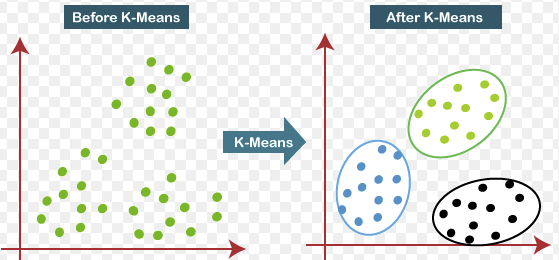

# K means clustering
RFM → rule-based segmentation

Clustering → data-driven segmentation


The rules are not written by us; the data itself finds the groups.

Clustering is the process of grouping objects with similar characteristics into the same cluster.

In marketing, this can mean customers with:

similar purchasing behavior

similar engagement levels

similar spending patterns

We can use RFM as features for clustering.

RFM is a simpler and more practical segmentation method.
Clustering is used for more complex behavioral segmentation because customer behavior is multidimensional, and it is not possible to manually define all the rules.

If we want to find hidden patterns → Clustering

Window shoppers → they browse but don’t buy

Deal hunters → they only purchase during discounts

Heavy users → they are very active

In digital marketing, the process often works like this:

Customer data → RFM is calculated → RFM + other behavioral metrics → Clustering → More precise segments

# K- Means clustering

---



##Automatically segment customers

Step 1: The number of clusters is determined. For example, we divide the data into 2 clusters.

Step 2: The K centers (centroids) are usually selected randomly (or sometimes initialized manually).

Step 3: The distance from each observation to the K centers is calculated, and each observation is assigned to the nearest center.

Step 4: This process is repeated multiple times, and the result with the smallest error is selected.

Note: How do we choose the value of K? If we don’t want to decide it manually, we can use certain methods (such as the Elbow method) to find the optimal K.

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Optional: Ignore warnings for better readability
import warnings
warnings.filterwarnings('ignore')

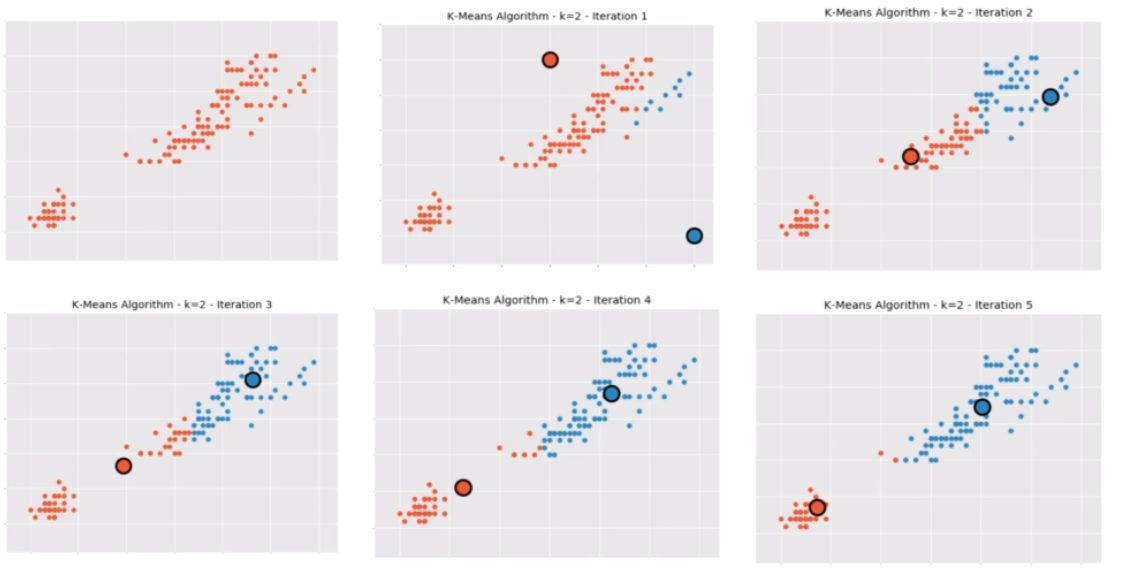

In [6]:
#Extract dataset
df =   pd.read_csv('https://raw.githubusercontent.com/HumayDS/A15---24-Reqemsal-data-analitika/refs/heads/main/customer_segmentation.csv')

In [8]:
pd.set_option('display.max_columns', None)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [9]:
df.shape

(2240, 29)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
cols = [
    'Income',
    'Recency',
    'Kidhome',
    'Teenhome',
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumStorePurchases'
]

df_cluster = df[cols]

Income → the customer’s purchasing power

Recency → number of days since the last purchase (activity level)

Kidhome → number of children at home (affects purchasing behavior)

Teenhome → number of teenagers at home

MntWines → spending on wine

MntMeatProducts → spending on meat products

MntFishProducts → spending on fish products

NumDealsPurchases → number of purchases made with discounts

NumWebPurchases → number of online purchases

NumStorePurchases → number of in-store purchases

In [12]:
#Check whether there are missing values (NA).
df_cluster.isnull().sum()

,0
Income,24
Recency,0
Kidhome,0
Teenhome,0
MntWines,0
MntMeatProducts,0
MntFishProducts,0
NumDealsPurchases,0
NumWebPurchases,0
NumStorePurchases,0


In [13]:
#Handling with NA's
df_cluster['Income'] = df_cluster['Income'].fillna(df_cluster['Income'].median())


In [14]:
#We check the categories.
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Income             2240 non-null   float64
 1   Recency            2240 non-null   int64  
 2   Kidhome            2240 non-null   int64  
 3   Teenhome           2240 non-null   int64  
 4   MntWines           2240 non-null   int64  
 5   MntMeatProducts    2240 non-null   int64  
 6   MntFishProducts    2240 non-null   int64  
 7   NumDealsPurchases  2240 non-null   int64  
 8   NumWebPurchases    2240 non-null   int64  
 9   NumStorePurchases  2240 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 175.1 KB


In [15]:
df_cluster.head()

,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases
0,58138.0,58,0,0,635,546,172,3,8,4
1,46344.0,38,1,1,11,6,2,2,1,2
2,71613.0,26,0,0,426,127,111,1,8,10
3,26646.0,26,1,0,11,20,10,2,2,4
4,58293.0,94,1,0,173,118,46,5,5,6


In [16]:
#Outlier analysis → Homework
df_cluster.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.00,2.0,3.00,15.0
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.00,4.0,6.00,27.0
NumStorePurchases,2240.0,5.790179,3.250958,0.0,3.00,5.0,8.00,13.0


1. Scaling – Important

There is the following problem in the dataset:

Income ≈ 50,000
MntWines ≈ 600
Recency ≈ 50

Because of these different scales, KMeans (since it calculates distance) may focus mostly on Income.
Therefore, the variables need to be scaled.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [18]:
X_scaled

array([[ 0.23569584,  0.30703926, -0.82521765, ...,  0.34941394,
         1.40930394, -0.55078479],
       [-0.23545419, -0.38366418,  1.03255877, ..., -0.16823634,
        -1.11040937, -1.1661254 ],
       [ 0.77399892, -0.79808624, -0.82521765, ..., -0.68588662,
         1.40930394,  1.29523705],
       ...,
       [ 0.18947568,  1.44669994, -0.82521765, ..., -0.68588662,
        -0.75045033,  2.21824797],
       [ 0.67940139, -1.41971934, -0.82521765, ..., -0.16823634,
         0.68938585,  1.29523705],
       [ 0.02520835, -0.31459383,  1.03255877, ...,  0.34941394,
        -0.39049128, -0.55078479]])

Finding the optimal number of clusters (Elbow Method)

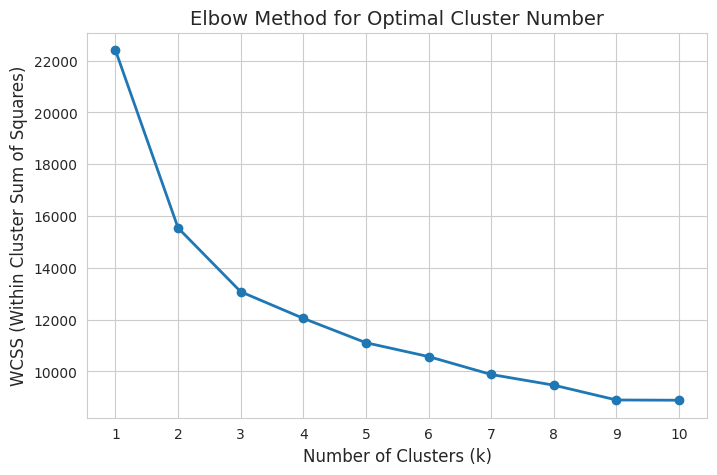

In [19]:
#The break point (elbow) in this graph represents the optimal number of clusters.
#After which point does the distance difference start to decrease?
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Drop rows with NaN values before scaling
X_scaled_cleaned = X_scaled[~pd.DataFrame(X_scaled).isnull().any(axis=1)]

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled_cleaned)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method for Optimal Cluster Number", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("WCSS (Within Cluster Sum of Squares)", fontsize=12)

plt.xticks(range(1,11))
plt.show()

In [20]:
#Add cluster number

kmeans = KMeans(n_clusters=4, random_state=42)

df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
df_cluster

,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases,Cluster
0,58138.0,58,0,0,635,546,172,3,8,4,1
1,46344.0,38,1,1,11,6,2,2,1,2,0
2,71613.0,26,0,0,426,127,111,1,8,10,1
3,26646.0,26,1,0,11,20,10,2,2,4,2
4,58293.0,94,1,0,173,118,46,5,5,6,2
...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,0,1,709,182,42,2,9,4,3
2236,64014.0,56,2,1,406,30,0,7,8,5,3
2237,56981.0,91,0,0,908,217,32,1,2,13,1
2238,69245.0,8,0,1,428,214,80,2,6,10,3


In [22]:
#How do the groups differ from each other?

df_cluster.groupby('Cluster').mean()

,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases
Cluster,,,,,,,,,,
0,42359.515625,49.640625,0.740234,1.029297,67.044922,24.835938,5.697266,2.568359,2.251953,3.472656
1,77109.233456,49.237132,0.051471,0.075368,624.095588,462.902574,100.071691,1.132353,4.998162,8.325368
2,30821.223491,48.861338,0.805873,0.000000,39.029364,32.399674,10.965742,1.876020,2.347471,3.282219
3,60392.574431,48.777583,0.164623,0.991243,495.719790,156.868651,34.989492,3.725044,6.723292,8.145359


##Cluster 0 – Family-Oriented Moderate Buyers
This cluster represents customers with moderate income who typically have children at home. Their spending on products such as wine, meat, and fish is relatively low, and they tend to make purchases mainly in physical stores rather than online. Overall, their buying behavior appears practical and focused on everyday needs rather than premium products.

Strategy:
Focus on family-oriented promotions, bundle offers, and in-store discounts to encourage larger basket sizes.

#Cluster 1 – Premium High-Value Customers
This cluster consists of high-income customers with the highest spending levels across most product categories, especially wine and meat. They make frequent purchases both online and in physical stores, indicating strong engagement with the brand and a high lifetime value.

Strategy:
Offer premium loyalty programs, personalized offers, and exclusive product recommendations to retain these valuable custome

#Cluster 2 – Low-Spending Budget Customers
Customers in this cluster have the lowest income levels and relatively low spending across all product categories. Their purchases appear occasional and price-sensitive, suggesting that they are careful with their spending and primarily buy essential items.

Strategy:
Use price promotions, discounts, and value-based product bundles to increase purchase frequency.

#Cluster 3 – Active Multi-Channel Spenders
This cluster includes customers with relatively high income and active purchasing behavior. They spend significantly on several product categories and make frequent purchases both online and in physical stores, showing strong engagement across multiple channels.

Strategy:
Leverage omnichannel marketing, targeted recommendations, and cross-selling strategies to further increase their spending and engagement.

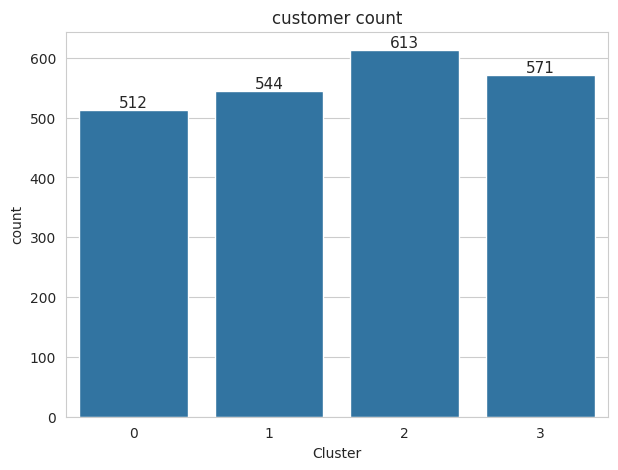

In [24]:
#Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

ax = sns.countplot(x='Cluster', data=df_cluster)

plt.title("customer count")

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.show()

In [25]:
#Let’s merge the Customer ID to identify the customers.
df_cluster = pd.concat([df['ID'], df_cluster], axis=1)

In [26]:
df_cluster

,ID,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases,Cluster
0,5524,58138.0,58,0,0,635,546,172,3,8,4,1
1,2174,46344.0,38,1,1,11,6,2,2,1,2,0
2,4141,71613.0,26,0,0,426,127,111,1,8,10,1
3,6182,26646.0,26,1,0,11,20,10,2,2,4,2
4,5324,58293.0,94,1,0,173,118,46,5,5,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,61223.0,46,0,1,709,182,42,2,9,4,3
2236,4001,64014.0,56,2,1,406,30,0,7,8,5,3
2237,7270,56981.0,91,0,0,908,217,32,1,2,13,1
2238,8235,69245.0,8,0,1,428,214,80,2,6,10,3


In [27]:
cluster_names = {
    0: "Moderate Customers",
    1: "Premium High Value Customers",
    2: "Low-Budget Customers",
    3: "Active Multi Channel Customers"
}

df_cluster["Cluster"] = df_cluster["Cluster"].map(cluster_names)

In [28]:

df_cluster

,ID,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases,Cluster
0,5524,58138.0,58,0,0,635,546,172,3,8,4,Premium High Value Customers
1,2174,46344.0,38,1,1,11,6,2,2,1,2,Moderate Customers
2,4141,71613.0,26,0,0,426,127,111,1,8,10,Premium High Value Customers
3,6182,26646.0,26,1,0,11,20,10,2,2,4,Low-Budget Customers
4,5324,58293.0,94,1,0,173,118,46,5,5,6,Low-Budget Customers
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,61223.0,46,0,1,709,182,42,2,9,4,Active Multi Channel Customers
2236,4001,64014.0,56,2,1,406,30,0,7,8,5,Active Multi Channel Customers
2237,7270,56981.0,91,0,0,908,217,32,1,2,13,Premium High Value Customers
2238,8235,69245.0,8,0,1,428,214,80,2,6,10,Active Multi Channel Customers


In [29]:
df_cluster[df_cluster["Cluster"] == "Moderate Customers"]

,ID,Income,Recency,Kidhome,Teenhome,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumWebPurchases,NumStorePurchases,Cluster
1,2174,46344.0,38,1,1,11,6,2,2,1,2,Moderate Customers
9,5899,5648.0,68,1,1,28,6,1,1,1,0,Moderate Customers
13,8180,59354.0,53,1,1,233,53,3,3,6,5,Moderate Customers
16,9736,41850.0,51,1,1,53,19,2,3,3,3,Moderate Customers
26,2404,53359.0,4,1,1,173,30,3,4,5,4,Moderate Customers
...,...,...,...,...,...,...,...,...,...,...,...,...
2212,6983,38054.0,24,1,1,23,17,2,2,2,3,Moderate Customers
2214,9303,5305.0,12,0,1,12,7,1,0,1,0,Moderate Customers
2215,692,36807.0,88,1,1,4,5,0,1,1,2,Moderate Customers
2223,1448,33562.0,33,1,2,21,12,0,3,2,4,Moderate Customers


In [30]:
df_cluster.to_csv("customers_clusters.csv", index=False)